# Project 2 — Feature Selection and Model Interpretability

Modern datasets often contain redundant, noisy, or highly correlated features. Feature selection tries to keep the variables that are most useful for prediction while reducing complexity. This is not only an accuracy problem. The selected features influence computation, generalization, interpretability, and scientific trust.

This project uses the Breast Cancer Wisconsin dataset from scikit-learn. The task is to classify tumors as malignant or benign from numerical measurements of cell nuclei, while studying how different feature selection and interpretation methods behave.

## Prerequisites

The notebook assumes basic knowledge of classification, train/test splitting, cross-validation, logistic regression, tree ensembles, and evaluation metrics. It also uses the ideas of correlation and mutual information. The explanations introduce the feature-selection methods before using them, so the notebook can be read as teaching material rather than only as code.

## Problem statement

Given numerical measurements computed from cell nuclei, classify whether a tumor is malignant or benign, while studying which features are most informative and how different feature selection methods behave.

This is a high-stakes style of problem, so interpretability must be handled carefully. A feature that helps a trained model make predictions is not automatically a causal medical factor. Feature importance is evidence about model behavior, not proof about disease mechanisms.

## Dataset description and source

The Breast Cancer Wisconsin dataset is available directly through `sklearn.datasets.load_breast_cancer`. It contains 569 samples and 30 numerical features derived from digitized images of fine needle aspirates of breast masses. The target has two classes: malignant and benign.

The features are organized around measurements such as radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension. Many measurements appear in three forms: mean, standard error, and worst value. This structure creates redundancy and correlation, making the dataset appropriate for feature selection and interpretability.

In [1]:
# Optional installation cell. SHAP is used only in an optional section.
# !pip install -U scikit-learn pandas numpy matplotlib seaborn shap

## Load libraries

The workflow uses pipelines wherever preprocessing is part of model fitting. This matters because feature selection can leak information if it is performed on the full dataset before train/test splitting or outside cross-validation.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif, RFE
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## Load and inspect the dataset

The dataset is clean and numerical, which lets us focus on feature selection rather than missing-value or categorical preprocessing. The class labels are converted into readable names for plots, while the model uses the numerical target.

In [3]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()

target_names = dict(enumerate(data.target_names))
print("Shape:", X.shape)
print("Target mapping:", target_names)
display(y.map(target_names).value_counts().to_frame("count"))
display(X.head())

Shape: (569, 30)
Target mapping: {0: 'malignant', 1: 'benign'}


,count
benign,357
malignant,212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Initial data inspection

Feature selection should begin by understanding the feature space. We inspect distributions, missing values, and correlations because selection methods behave differently when features are redundant, differently scaled, or strongly related to one another.

,dtype,missing,mean,std,min,max
mean radius,float64,0,14.127,3.524,6.981,28.110
mean texture,float64,0,19.290,4.301,9.710,39.280
mean perimeter,float64,0,91.969,24.299,43.790,188.500
mean area,float64,0,654.889,351.914,143.500,2501.000
mean smoothness,float64,0,0.096,0.014,0.053,0.163
mean compactness,float64,0,0.104,0.053,0.019,0.345
mean concavity,float64,0,0.089,0.080,0.000,0.427
mean concave points,float64,0,0.049,0.039,0.000,0.201
mean symmetry,float64,0,0.181,0.027,0.106,0.304
mean fractal dimension,float64,0,0.063,0.007,0.050,0.097


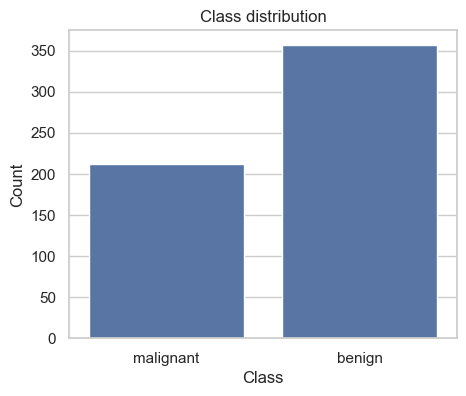

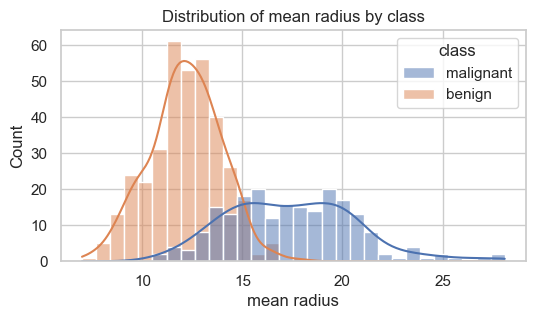

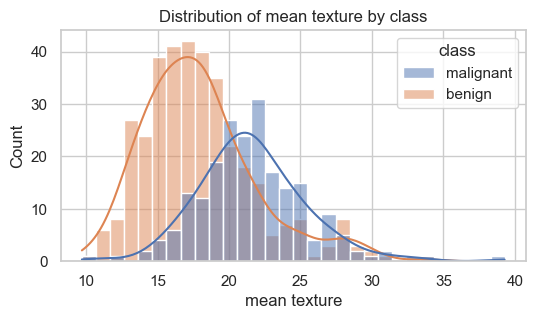

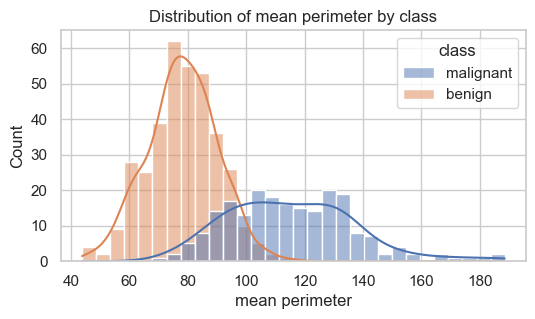

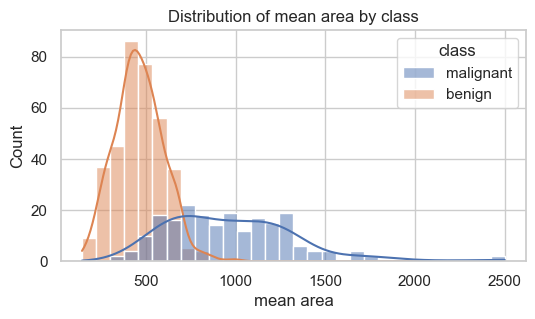

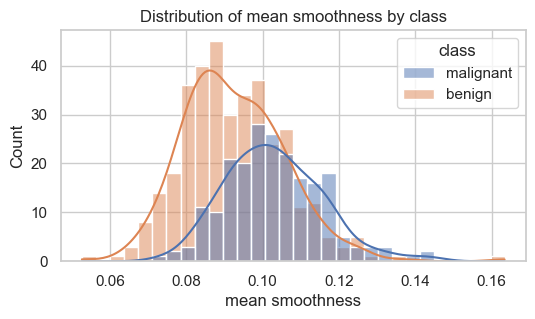

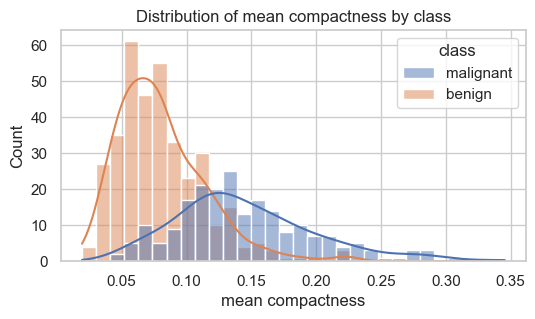

In [4]:
summary = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "mean": X.mean(),
    "std": X.std(),
    "min": X.min(),
    "max": X.max()
})
display(summary.round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=y.map(target_names), ax=ax)
ax.set_title("Class distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

for col in X.columns[:6]:
    fig, ax = plt.subplots(figsize=(6, 3))
    sns.histplot(data=pd.concat([X[[col]], y.map(target_names).rename("class")], axis=1),
                 x=col, hue="class", bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col} by class")
    plt.show()

### Correlation heatmap

The feature names already suggest redundancy: mean, error, and worst versions of related measurements often move together. Correlated predictors can make coefficients unstable and can make importance scores difficult to interpret because the model may distribute credit across similar variables.

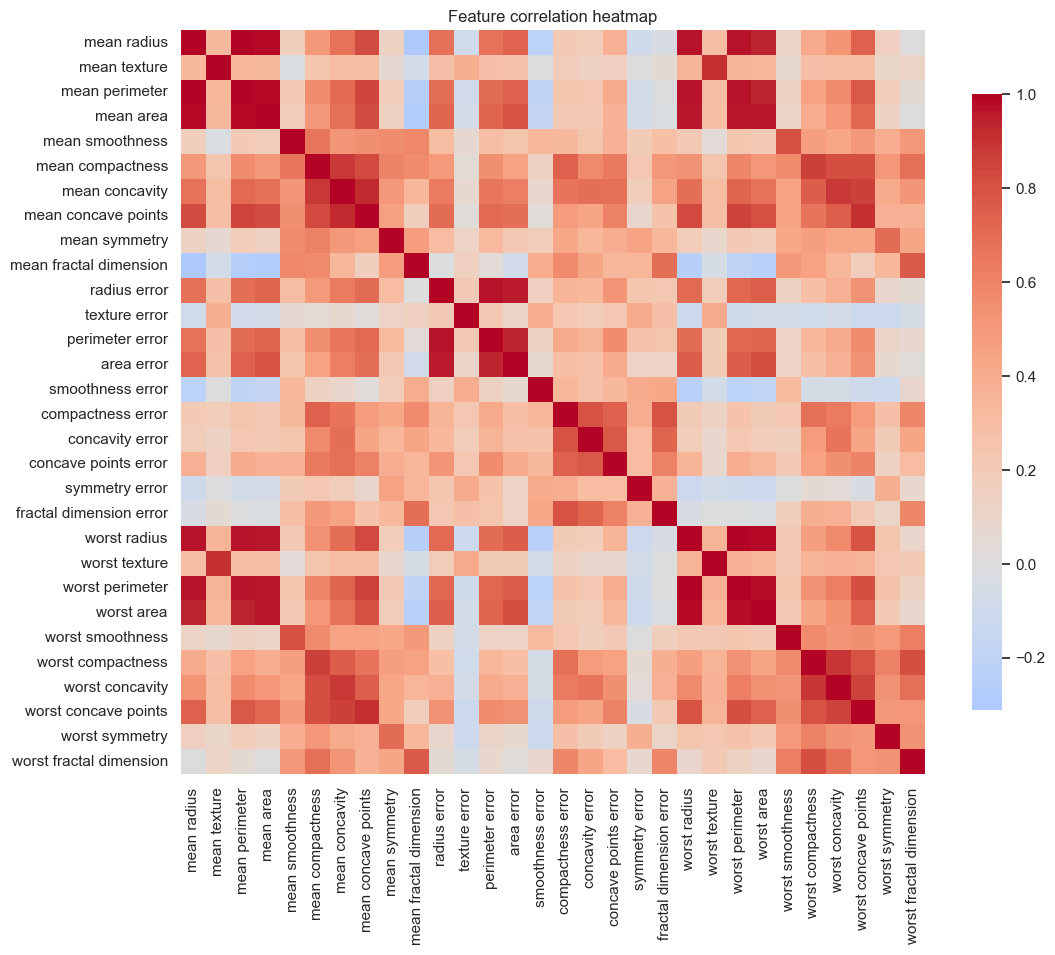

In [5]:
corr = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature correlation heatmap")
plt.show()

## Train/validation/test split

The validation set is used for feature-selection comparisons, while the test set is reserved for final checks. When a method uses scaling or model fitting, it is applied using only the training data.

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Validation:", X_valid.shape, "Test:", X_test.shape)

Train: (341, 30) Validation: (114, 30) Test: (114, 30)


## Utility functions

The same metrics are collected for all models so that feature subsets can be compared against the all-feature baseline. In a real medical setting, the cost of false negatives and false positives should be defined with domain experts; here we report several metrics instead of optimizing only one.

In [7]:
selection_results = {}
comparison_rows = []

def metric_row(name, model_label, model, X_tr, y_tr, X_val, y_val, selected_features=None, note=""):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_val)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_val)[:, 1]
    else:
        score = model.decision_function(X_val)

    row = {
        "method": name,
        "model": model_label,
        "n_features": len(selected_features) if selected_features is not None else X_tr.shape[1],
        "selected_features": list(selected_features) if selected_features is not None else list(X_tr.columns),
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, score),
        "interpretation_note": note
    }
    comparison_rows.append(row)
    return row

def comparison_table():
    df = pd.DataFrame(comparison_rows).drop_duplicates(subset=["method", "model", "n_features"], keep="last")
    for col in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        df[col] = df[col].round(4)
    return df.sort_values(["roc_auc", "f1"], ascending=False).reset_index(drop=True)

def plot_metric_by_k(df, title, x="k", y="roc_auc"):
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.lineplot(data=df, x=x, y=y, marker="o", ax=ax)
    ax.set_title(title)
    ax.set_ylabel(y.upper())
    plt.show()

## Baseline model with all features

The baseline establishes how well the model performs when it uses all available information. Feature selection should be compared against this baseline, not judged in isolation. If a selected subset performs similarly with fewer variables, the simpler model may still be useful even without a large accuracy gain.

In [8]:
logreg_all = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
])

rf_all = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

metric_row(
    "All features", "LogisticRegression", logreg_all,
    X_train, y_train, X_valid, y_valid,
    selected_features=X_train.columns,
    note="All numerical features with scaling; useful reference for linear model selection."
)

metric_row(
    "All features", "RandomForest", rf_all,
    X_train, y_train, X_valid, y_valid,
    selected_features=X_train.columns,
    note="All numerical features with a tree ensemble; captures nonlinearities and interactions."
)

display(comparison_table()[["method", "model", "n_features", "accuracy", "precision", "recall", "f1", "roc_auc", "interpretation_note"]])

,method,model,n_features,accuracy,precision,recall,f1,roc_auc,interpretation_note
0,All features,LogisticRegression,30,0.9737,0.9857,0.9718,0.9787,0.9974,All numerical features with scaling; useful re...
1,All features,RandomForest,30,0.9561,0.9714,0.9577,0.9645,0.9846,All numerical features with a tree ensemble; c...


## Correlation analysis and redundancy

Correlation measures linear association between two features. Highly correlated features often carry overlapping information. Removing one of two highly correlated features can simplify the model and reduce coefficient instability, especially for linear models. However, correlation between features is not the same as usefulness for predicting the target; a feature can be redundant with another feature and still be predictive.

In [9]:
def correlation_reduction_features(X_train, threshold=0.95):
    corr_abs = X_train.corr().abs()
    upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    selected = [c for c in X_train.columns if c not in to_drop]
    pairs = (
        upper.stack()
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
        .query("abs_corr > @threshold")
        .sort_values("abs_corr", ascending=False)
    )
    return selected, to_drop, pairs

corr_selected, corr_dropped, high_corr_pairs = correlation_reduction_features(X_train, threshold=0.95)
print("Number dropped:", len(corr_dropped))
display(high_corr_pairs.head(20))
print("Selected features:", corr_selected)

logreg_corr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
])

metric_row(
    "Correlation-reduced", "LogisticRegression", logreg_corr,
    X_train[corr_selected], y_train, X_valid[corr_selected], y_valid,
    selected_features=corr_selected,
    note="Drops one feature from highly correlated pairs to reduce redundancy."
)

display(comparison_table()[["method", "model", "n_features", "accuracy", "precision", "recall", "f1", "roc_auc"]])

Number dropped: 7


,feature_1,feature_2,abs_corr
1,mean radius,mean perimeter,0.998000
391,worst radius,worst perimeter,0.993781
2,mean radius,mean area,0.988009
57,mean perimeter,mean area,0.986979
392,worst radius,worst area,0.984961
407,worst perimeter,worst area,0.977912
246,radius error,perimeter error,0.974879
76,mean perimeter,worst perimeter,0.969900
19,mean radius,worst radius,0.969409
74,mean perimeter,worst radius,0.968967


Selected features: ['mean radius', 'mean texture', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst texture', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


,method,model,n_features,accuracy,precision,recall,f1,roc_auc
0,Correlation-reduced,LogisticRegression,23,0.9825,0.9859,0.9859,0.9859,0.9974
1,All features,LogisticRegression,30,0.9737,0.9857,0.9718,0.9787,0.9974
2,All features,RandomForest,30,0.9561,0.9714,0.9577,0.9645,0.9846


## Univariate statistical feature selection

Univariate methods score each feature independently with respect to the target. They are fast and simple, but they ignore interactions. A feature that looks weak alone may still become useful in combination with others. Therefore, univariate selection is best treated as screening rather than final truth.

`f_classif` compares class-wise variation for each feature. `chi2` requires non-negative features, so the code uses MinMax scaling before applying it.

,k,roc_auc,f1
0,5,0.9777,0.9650
1,10,0.9781,0.9510
2,15,0.9895,0.9504
3,20,0.9977,0.9787
4,30,0.9974,0.9787


,k,roc_auc,f1
0,5,0.9748,0.9524
1,10,0.9761,0.9444
2,15,0.9810,0.9510
3,20,0.9898,0.9793
4,30,0.9915,0.9793


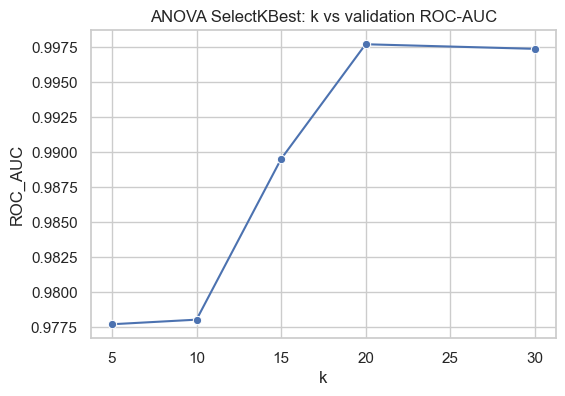

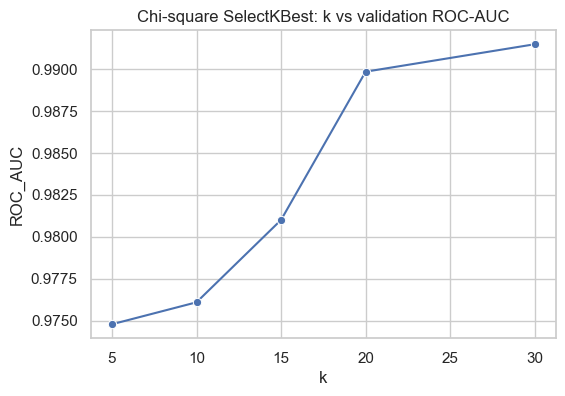

In [10]:
k_values = [5, 10, 15, 20, 30]
anova_rows = []
chi_rows = []

for k in k_values:
    # ANOVA F-test
    selector_f = SelectKBest(score_func=f_classif, k=k)
    selector_f.fit(X_train, y_train)
    selected_f = X_train.columns[selector_f.get_support()].tolist()

    model_f = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ])
    row_f = metric_row(
        f"SelectKBest f_classif k={k}", "LogisticRegression", model_f,
        X_train[selected_f], y_train, X_valid[selected_f], y_valid,
        selected_features=selected_f,
        note="Fast univariate screening; ignores interactions among features."
    )
    anova_rows.append({"k": k, "roc_auc": row_f["roc_auc"], "f1": row_f["f1"]})

    # Chi-square with non-negative scaling
    chi_pipe = Pipeline([
        ("minmax", MinMaxScaler()),
        ("select", SelectKBest(score_func=chi2, k=k)),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ])
    chi_pipe.fit(X_train, y_train)
    selected_chi = X_train.columns[chi_pipe.named_steps["select"].get_support()].tolist()

    row_chi = metric_row(
        f"SelectKBest chi2 k={k}", "LogisticRegression", chi_pipe,
        X_train, y_train, X_valid, y_valid,
        selected_features=selected_chi,
        note="Univariate count-style association after MinMax scaling to satisfy non-negativity."
    )
    chi_rows.append({"k": k, "roc_auc": row_chi["roc_auc"], "f1": row_chi["f1"]})

anova_df = pd.DataFrame(anova_rows)
chi_df = pd.DataFrame(chi_rows)

display(anova_df.round(4))
display(chi_df.round(4))

plot_metric_by_k(anova_df, "ANOVA SelectKBest: k vs validation ROC-AUC")
plot_metric_by_k(chi_df, "Chi-square SelectKBest: k vs validation ROC-AUC")

### A small leakage demonstration for feature selection

Feature selection must be treated as part of model training. If we select features once using the entire training set and then cross-validate only the classifier, each validation fold has already influenced the selected feature set. The difference may be small on this clean dataset, but the workflow is still optimistic. The proper version places `SelectKBest` inside the pipeline so that selection is repeated independently inside each cross-validation fold.

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

proper_selection_pipeline = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=10)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
])
proper_scores = cross_val_score(
    proper_selection_pipeline, X_train_full, y_train_full,
    cv=cv, scoring="roc_auc", n_jobs=-1
)

# Intentionally leaky comparison: the selector sees all of X_train_full before CV begins.
leaky_selector = SelectKBest(score_func=f_classif, k=10).fit(X_train_full, y_train_full)
leaky_features = X_train_full.columns[leaky_selector.get_support()].tolist()
leaky_classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
])
leaky_scores = cross_val_score(
    leaky_classifier, X_train_full[leaky_features], y_train_full,
    cv=cv, scoring="roc_auc", n_jobs=-1
)

leakage_demo = pd.DataFrame({
    "workflow": ["Proper pipeline selection inside each fold", "Leaky pre-selection before cross-validation"],
    "mean_cv_roc_auc": [proper_scores.mean(), leaky_scores.mean()],
    "std_cv_roc_auc": [proper_scores.std(), leaky_scores.std()],
    "selected_features_visible_before_cv": ["No", "Yes"]
})
display(leakage_demo.round(4))
print("Leaky selected features:", leaky_features)


,workflow,mean_cv_roc_auc,std_cv_roc_auc,selected_features_visible_before_cv
0,Proper pipeline selection inside each fold,0.9867,0.0066,No
1,Leaky pre-selection before cross-validation,0.9867,0.0066,Yes


Leaky selected features: ['mean radius', 'mean perimeter', 'mean area', 'mean concavity', 'mean concave points', 'worst radius', 'worst perimeter', 'worst area', 'worst concavity', 'worst concave points']


## Mutual information

Mutual information measures how much knowing one variable reduces uncertainty about another. Unlike simple correlation, it can capture nonlinear relationships. In practice, MI estimates can be noisy, especially with limited data, so it is useful as a ranking signal rather than an unquestionable truth.

,feature,mutual_information
22,worst perimeter,0.473153
20,worst radius,0.465186
7,mean concave points,0.460651
23,worst area,0.452752
27,worst concave points,0.451801
2,mean perimeter,0.409273
6,mean concavity,0.352609
0,mean radius,0.337765
3,mean area,0.336319
13,area error,0.328567


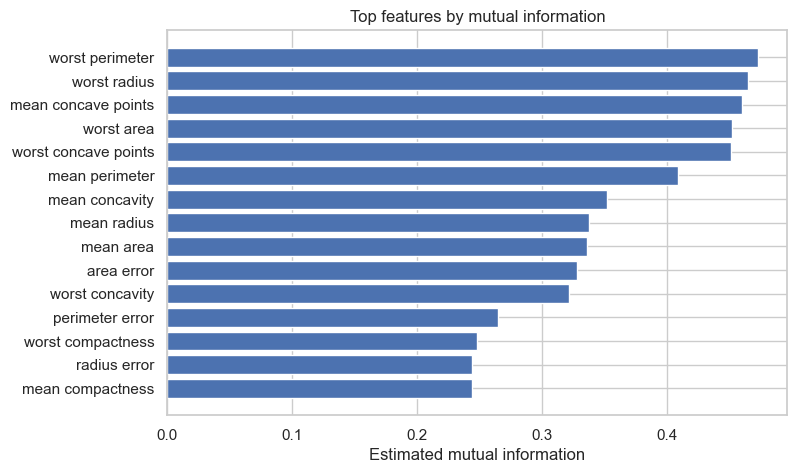

,k,roc_auc,f1
0,5,0.9784,0.9650
1,10,0.9862,0.9718
2,15,0.9895,0.9504
3,20,0.9951,0.9645
4,30,0.9974,0.9787


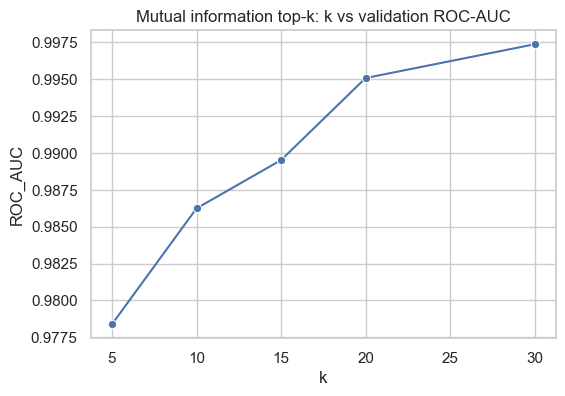

In [12]:
mi = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": X_train.columns, "mutual_information": mi}).sort_values("mutual_information", ascending=False)

display(mi_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_mi = mi_df.head(15).sort_values("mutual_information")
ax.barh(top_mi["feature"], top_mi["mutual_information"])
ax.set_title("Top features by mutual information")
ax.set_xlabel("Estimated mutual information")
plt.show()

mi_rows = []
for k in k_values:
    selected_mi = mi_df.head(k)["feature"].tolist()
    model_mi = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ])
    row_mi = metric_row(
        f"Mutual information top-{k}", "LogisticRegression", model_mi,
        X_train[selected_mi], y_train, X_valid[selected_mi], y_valid,
        selected_features=selected_mi,
        note="Ranks features by estimated dependence with the target, including possible nonlinear dependence."
    )
    mi_rows.append({"k": k, "roc_auc": row_mi["roc_auc"], "f1": row_mi["f1"]})

mi_perf = pd.DataFrame(mi_rows)
display(mi_perf.round(4))
plot_metric_by_k(mi_perf, "Mutual information top-k: k vs validation ROC-AUC")

## Embedded method: L1-regularized logistic regression

L1 regularization encourages some coefficients to become exactly zero. This makes Lasso-style models useful for feature selection. The regularization strength is controlled by `C`: smaller `C` means stronger regularization and usually fewer selected features; larger `C` means weaker regularization and usually more selected features.

A useful setting is not necessarily the one that selects the fewest features or the one with the highest training score. We want a balance between simplicity and validation performance.

,C,n_selected,roc_auc,f1
0,0.001,0,0.5000,0.0000
1,0.010,2,0.9486,0.9231
2,0.100,7,0.9836,0.9718
3,1.000,13,0.9971,0.9718
4,10.000,23,0.9971,0.9718


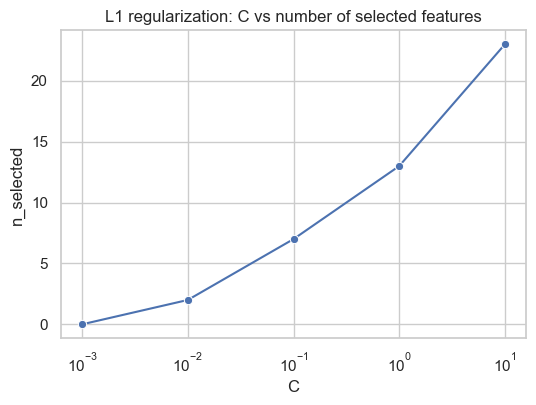

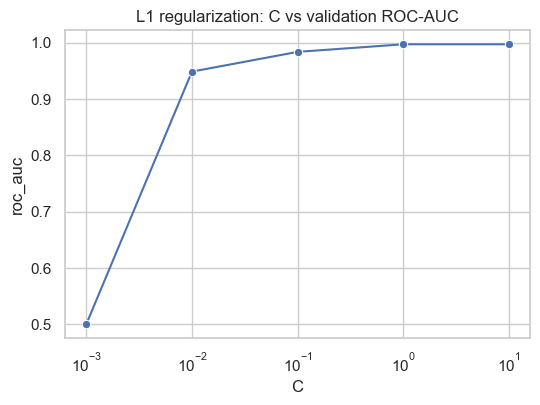

In [13]:
C_values = [0.001, 0.01, 0.1, 1, 10]
l1_rows = []

for C in C_values:
    l1_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1", solver="liblinear", C=C,
            class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE
        ))
    ])
    l1_model.fit(X_train, y_train)
    coef = l1_model.named_steps["model"].coef_.ravel()
    selected_l1 = X_train.columns[np.abs(coef) > 1e-8].tolist()

    row = metric_row(
        f"L1 logistic C={C}", "LogisticRegression", l1_model,
        X_train, y_train, X_valid, y_valid,
        selected_features=selected_l1,
        note="Embedded selection through sparse coefficients; sensitive to scaling and regularization strength."
    )
    l1_rows.append({
        "C": C,
        "n_selected": len(selected_l1),
        "roc_auc": row["roc_auc"],
        "f1": row["f1"],
        "selected_features": selected_l1
    })

l1_df = pd.DataFrame(l1_rows)
display(l1_df[["C", "n_selected", "roc_auc", "f1"]].round(4))

fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(data=l1_df, x="C", y="n_selected", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_title("L1 regularization: C vs number of selected features")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(data=l1_df, x="C", y="roc_auc", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_title("L1 regularization: C vs validation ROC-AUC")
plt.show()

## Wrapper method: Recursive Feature Elimination

Recursive Feature Elimination trains a model repeatedly, removes the least important features, and continues until a desired number remains. Because it evaluates features through a model, it can capture some model-specific behavior that simple filter methods miss. The cost is computation: RFE is slower than correlation filtering or univariate selection.

RFE is model-dependent. Features selected by RFE with logistic regression may differ from those selected by a tree model.

,k,roc_auc,f1
0,5,0.9938,0.9718
1,10,0.9938,0.9650
2,15,0.9977,0.9787
3,20,0.9967,0.9787


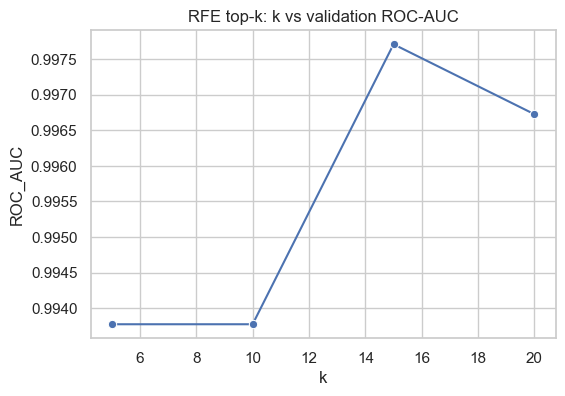

In [14]:
rfe_rows = []
for k in [5, 10, 15, 20]:
    estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ])

    # RFE needs direct access to coef_, so wrap scaling outside the estimator for selection.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
    X_valid_scaled = pd.DataFrame(scaler.transform(X_valid), columns=X_valid.columns, index=X_valid.index)

    rfe = RFE(
        estimator=LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE),
        n_features_to_select=k
    )
    rfe.fit(X_train_scaled, y_train)
    selected_rfe = X_train.columns[rfe.support_].tolist()

    model_rfe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
    ])

    row = metric_row(
        f"RFE logistic k={k}", "LogisticRegression", model_rfe,
        X_train[selected_rfe], y_train, X_valid[selected_rfe], y_valid,
        selected_features=selected_rfe,
        note="Wrapper selection; repeatedly removes features according to the fitted logistic model."
    )
    rfe_rows.append({"k": k, "roc_auc": row["roc_auc"], "f1": row["f1"], "selected_features": selected_rfe})

rfe_df = pd.DataFrame(rfe_rows)
display(rfe_df[["k", "roc_auc", "f1"]].round(4))
plot_metric_by_k(rfe_df, "RFE top-k: k vs validation ROC-AUC")

## Tree-based feature importance

Tree ensembles estimate feature importance from how much features reduce impurity or improve splits. These importances are convenient, but they can be biased toward continuous variables or variables with many possible split points. They are useful as one perspective, not as the final explanation.

,feature,impurity_importance
27,worst concave points,0.155357
22,worst perimeter,0.132378
23,worst area,0.115604
7,mean concave points,0.104313
20,worst radius,0.074266
6,mean concavity,0.068000
26,worst concavity,0.048326
2,mean perimeter,0.037956
0,mean radius,0.033734
13,area error,0.033060


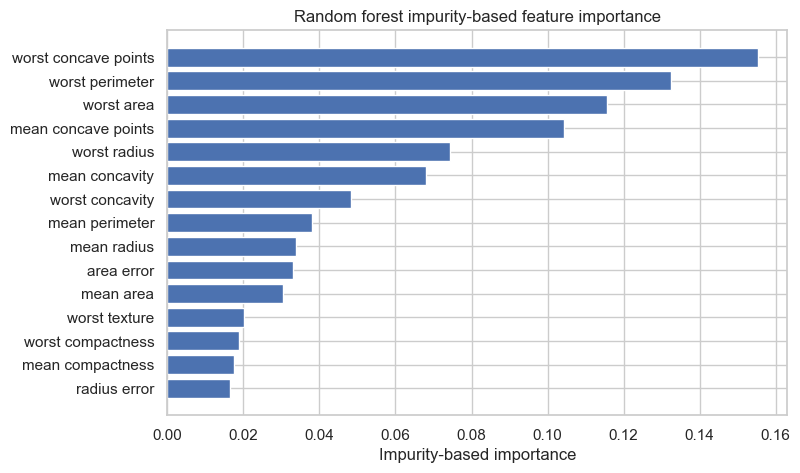

In [15]:
rf_importance_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_importance_model.fit(X_train, y_train)

rf_imp_df = pd.DataFrame({
    "feature": X_train.columns,
    "impurity_importance": rf_importance_model.feature_importances_
}).sort_values("impurity_importance", ascending=False)

display(rf_imp_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_rf = rf_imp_df.head(15).sort_values("impurity_importance")
ax.barh(top_rf["feature"], top_rf["impurity_importance"])
ax.set_title("Random forest impurity-based feature importance")
ax.set_xlabel("Impurity-based importance")
plt.show()

for k in [5, 10, 15, 20]:
    selected_tree = rf_imp_df.head(k)["feature"].tolist()
    model_tree_top = RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
    )
    metric_row(
        f"Tree impurity top-{k}", "RandomForest", model_tree_top,
        X_train[selected_tree], y_train, X_valid[selected_tree], y_valid,
        selected_features=selected_tree,
        note="Uses random forest split-based importance; convenient but can be biased."
    )

## Permutation importance

Permutation importance measures how much performance drops when a feature is randomly shuffled. It is model-agnostic and closer to the question: “How much does this trained model rely on this feature?” It should still be interpreted carefully because correlated features can compensate for one another.

,feature,importance_mean,importance_std
21,worst texture,0.007173,0.003485
27,worst concave points,0.001867,0.006100
26,worst concavity,0.001638,0.004312
23,worst area,0.001507,0.006539
28,worst symmetry,0.001196,0.001311
1,mean texture,0.001179,0.000764
6,mean concavity,0.000983,0.005155
22,worst perimeter,0.000950,0.006721
5,mean compactness,0.000753,0.001705
7,mean concave points,0.000721,0.005619


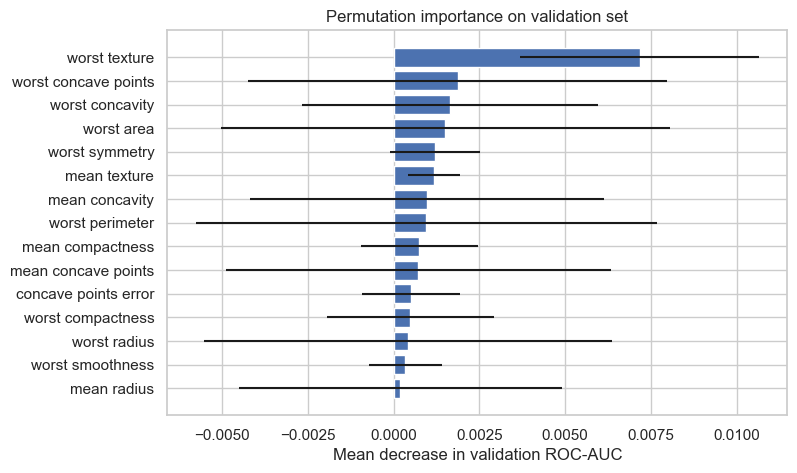

In [16]:
perm = permutation_importance(
    rf_importance_model, X_valid, y_valid,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_perm = perm_df.head(15).sort_values("importance_mean")
ax.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
ax.set_title("Permutation importance on validation set")
ax.set_xlabel("Mean decrease in validation ROC-AUC")
plt.show()

for k in [5, 10, 15, 20]:
    selected_perm = perm_df.head(k)["feature"].tolist()
    model_perm_top = RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2,
        class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
    )
    metric_row(
        f"Permutation importance top-{k}", "RandomForest", model_perm_top,
        X_train[selected_perm], y_train, X_valid[selected_perm], y_valid,
        selected_features=selected_perm,
        note="Uses validation-set model dependence; affected by correlated predictors."
    )

## Comparing coefficient, impurity, and permutation views

Different methods answer different questions. Logistic coefficients describe a scaled linear model. Random forest impurity importance describes how often and how strongly features help tree splits. Permutation importance describes how much a trained model’s validation performance depends on a feature. Agreement across methods is stronger evidence of predictive relevance; disagreement often reveals redundancy or model-specific behavior.

,feature,abs_scaled_coefficient,impurity_importance,importance_mean
1,worst texture,1.111987,0.020254,0.007173
2,worst concave points,0.996047,0.155357,0.001867
9,worst concavity,0.672442,0.048326,0.001638
4,worst area,0.911003,0.115604,0.001507
6,worst symmetry,0.805731,0.010280,0.001196
12,mean texture,0.545206,0.011288,0.001179
20,mean concavity,0.379610,0.068000,0.000983
7,worst perimeter,0.745659,0.132378,0.000950
10,mean compactness,0.670897,0.017442,0.000753
8,mean concave points,0.673818,0.104313,0.000721


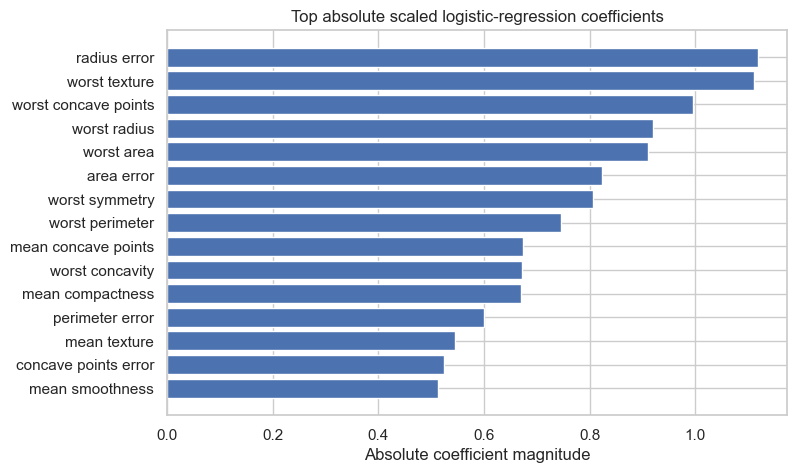

In [17]:
# Logistic coefficient view from the all-feature baseline
logreg_all.fit(X_train, y_train)
coefs = logreg_all.named_steps["model"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "abs_scaled_coefficient": np.abs(coefs),
    "coefficient": coefs
}).sort_values("abs_scaled_coefficient", ascending=False)

merged_importance = (
    coef_df[["feature", "abs_scaled_coefficient"]]
    .merge(rf_imp_df, on="feature", how="outer")
    .merge(perm_df[["feature", "importance_mean"]], on="feature", how="outer")
)

display(merged_importance.sort_values("importance_mean", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_coef = coef_df.head(15).sort_values("abs_scaled_coefficient")
ax.barh(top_coef["feature"], top_coef["abs_scaled_coefficient"])
ax.set_title("Top absolute scaled logistic-regression coefficients")
ax.set_xlabel("Absolute coefficient magnitude")
plt.show()

## SHAP basics: optional model explanation

SHAP values explain predictions by estimating how much each feature contributes to moving a prediction away from a baseline value. SHAP can be used for global interpretation, such as average feature impact, and local interpretation, such as why one sample received a high predicted probability.

SHAP explains the trained model, not the real disease process. The section is optional because SHAP may not be installed in every environment.

In [18]:
try:
    import shap

    # Use a tree model for a compact SHAP demonstration.
    shap_model = GradientBoostingClassifier(random_state=RANDOM_STATE)
    shap_model.fit(X_train, y_train)

    explainer = shap.Explainer(shap_model, X_train)
    shap_values = explainer(X_valid.iloc[:100])

    shap.plots.bar(shap_values, max_display=15)
    shap.plots.beeswarm(shap_values, max_display=15)

except Exception as e:
    print("SHAP section skipped.")
    print("Reason:", repr(e))
    print("Install or update SHAP if you want to run this optional interpretation section.")

SHAP section skipped.
Reason: ExplainerError('Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was -3.317764, while the model output was -3.125604. If this difference is acceptable you can set check_additivity=False to disable this check.')
Install or update SHAP if you want to run this optional interpretation section.


## Stability of feature selection

A feature selection method is more trustworthy if it selects similar features across different data splits. If selected features change drastically with small changes in data, interpretation should be cautious. Instability does not always mean the model is useless; it may mean that predictors are correlated or interchangeable.

In [19]:
from collections import Counter
from sklearn.model_selection import RepeatedStratifiedKFold

def stability_experiment(X, y, n_splits=5, n_repeats=2, k=10):
    counters = {
        "L1_logistic": Counter(),
        "Mutual_information": Counter(),
        "RFE_logistic": Counter()
    }

    splitter = RepeatedStratifiedKFold(
        n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE
    )
    total_splits = 0

    for split_id, (train_idx, _) in enumerate(splitter.split(X, y), start=1):
        total_splits += 1
        X_tr = X.iloc[train_idx]
        y_tr = y.iloc[train_idx] if hasattr(y, "iloc") else y[train_idx]

        # L1 logistic selection
        l1 = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="l1", solver="liblinear", C=0.1,
                class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE + split_id
            ))
        ])
        l1.fit(X_tr, y_tr)
        l1_coef = l1.named_steps["model"].coef_.ravel()
        l1_selected = X.columns[np.abs(l1_coef) > 1e-8].tolist()
        counters["L1_logistic"].update(l1_selected)

        # Mutual information top-k selection
        mi_split = mutual_info_classif(X_tr, y_tr, random_state=RANDOM_STATE + split_id)
        mi_selected = X.columns[np.argsort(mi_split)[::-1][:k]].tolist()
        counters["Mutual_information"].update(mi_selected)

        # RFE top-k selection
        scaler = StandardScaler()
        X_tr_scaled = pd.DataFrame(scaler.fit_transform(X_tr), columns=X.columns, index=X_tr.index)
        rfe = RFE(
            LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE + split_id),
            n_features_to_select=k
        )
        rfe.fit(X_tr_scaled, y_tr)
        rfe_selected = X.columns[rfe.support_].tolist()
        counters["RFE_logistic"].update(rfe_selected)

    stability_tables = {}
    for method, counter in counters.items():
        stability_tables[method] = (
            pd.DataFrame(counter.items(), columns=["feature", "selection_count"])
            .assign(selection_frequency=lambda d: d["selection_count"] / total_splits)
            .sort_values(["selection_frequency", "feature"], ascending=[False, True])
        )

    return stability_tables

stability_tables = stability_experiment(X_train_full, y_train_full, n_splits=5, n_repeats=2, k=10)

for method, table in stability_tables.items():
    print("\n", method)
    display(table.head(15))


 L1_logistic


,feature,selection_count,selection_frequency
0,mean concave points,10,1.0
5,worst concave points,10,1.0
2,worst radius,10,1.0
6,worst symmetry,10,1.0
3,worst texture,10,1.0
1,radius error,9,0.9
4,worst smoothness,9,0.9
7,mean texture,4,0.4
8,worst perimeter,1,0.1



 Mutual_information


,feature,selection_count,selection_frequency
6,mean area,10,1.0
1,mean concave points,10,1.0
8,mean concavity,10,1.0
5,mean perimeter,10,1.0
7,mean radius,10,1.0
2,worst area,10,1.0
4,worst concave points,10,1.0
0,worst perimeter,10,1.0
3,worst radius,10,1.0
9,area error,7,0.7



 RFE_logistic


,feature,selection_count,selection_frequency
3,area error,10,1.0
2,radius error,10,1.0
7,worst area,10,1.0
9,worst concave points,10,1.0
6,worst perimeter,10,1.0
4,worst radius,10,1.0
5,worst texture,10,1.0
0,mean concave points,7,0.7
8,worst smoothness,5,0.5
12,compactness error,4,0.4


### Connecting stability with importance rankings

A feature that appears repeatedly across splits is often a safer candidate for interpretation than a feature selected only once. The next cell compares stable features with permutation importance. Agreement between these views strengthens confidence that the model relies on a feature consistently; disagreement is a useful warning sign, especially when features are correlated.

,feature,importance_mean,importance_std
13,worst texture,0.0072,0.0035
8,worst concave points,0.0019,0.0061
7,worst area,0.0015,0.0065
12,worst symmetry,0.0012,0.0013
3,mean concavity,0.0010,0.0052
9,worst perimeter,0.0009,0.0067
2,mean concave points,0.0007,0.0056
10,worst radius,0.0004,0.0059
11,worst smoothness,0.0003,0.0011
5,mean radius,0.0002,0.0047


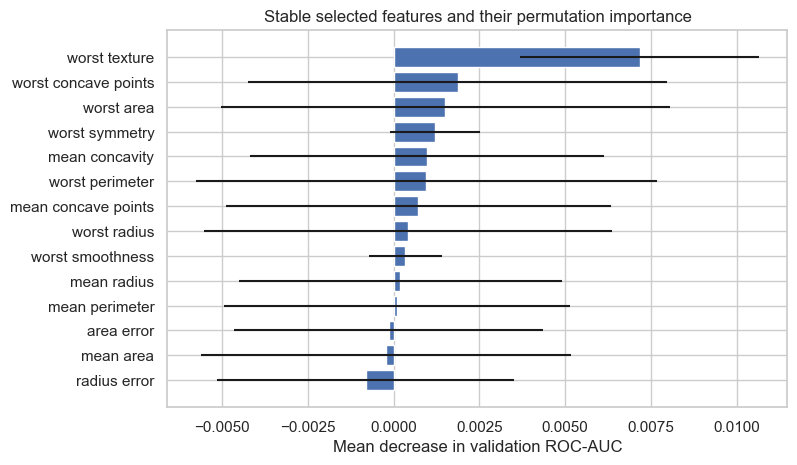

In [20]:
stable_union = set()
for method, table in stability_tables.items():
    stable_union.update(table.loc[table["selection_frequency"] >= 0.8, "feature"].tolist())

stable_vs_perm = pd.DataFrame({"feature": sorted(stable_union)})
stable_vs_perm = stable_vs_perm.merge(
    perm_df[["feature", "importance_mean", "importance_std"]],
    on="feature", how="left"
).sort_values("importance_mean", ascending=False)

display(stable_vs_perm.round(4))

if len(stable_vs_perm) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(stable_vs_perm))))
    plot_stable = stable_vs_perm.sort_values("importance_mean")
    ax.barh(plot_stable["feature"], plot_stable["importance_mean"], xerr=plot_stable["importance_std"])
    ax.set_title("Stable selected features and their permutation importance")
    ax.set_xlabel("Mean decrease in validation ROC-AUC")
    plt.show()

## Comparing feature selection methods

The summary table brings together filter methods, wrapper methods, embedded methods, and importance-based methods. Do not read the table as a competition where the highest score is automatically best. A smaller model with nearly identical performance may be preferable, especially when interpretability and measurement cost matter.

,method,model,n_features,accuracy,precision,recall,f1,roc_auc,interpretation_note
0,SelectKBest f_classif k=20,LogisticRegression,20,0.9737,0.9857,0.9718,0.9787,0.9977,Fast univariate screening; ignores interaction...
1,RFE logistic k=15,LogisticRegression,15,0.9737,0.9857,0.9718,0.9787,0.9977,Wrapper selection; repeatedly removes features...
2,Correlation-reduced,LogisticRegression,23,0.9825,0.9859,0.9859,0.9859,0.9974,Drops one feature from highly correlated pairs...
3,All features,LogisticRegression,30,0.9737,0.9857,0.9718,0.9787,0.9974,All numerical features with scaling; useful re...
4,SelectKBest f_classif k=30,LogisticRegression,30,0.9737,0.9857,0.9718,0.9787,0.9974,Fast univariate screening; ignores interaction...
5,Mutual information top-30,LogisticRegression,30,0.9737,0.9857,0.9718,0.9787,0.9974,Ranks features by estimated dependence with th...
6,L1 logistic C=1,LogisticRegression,13,0.9649,0.9718,0.9718,0.9718,0.9971,Embedded selection through sparse coefficients...
7,L1 logistic C=10,LogisticRegression,23,0.9649,0.9718,0.9718,0.9718,0.9971,Embedded selection through sparse coefficients...
8,RFE logistic k=20,LogisticRegression,20,0.9737,0.9857,0.9718,0.9787,0.9967,Wrapper selection; repeatedly removes features...
9,Mutual information top-20,LogisticRegression,20,0.9561,0.9714,0.9577,0.9645,0.9951,Ranks features by estimated dependence with th...


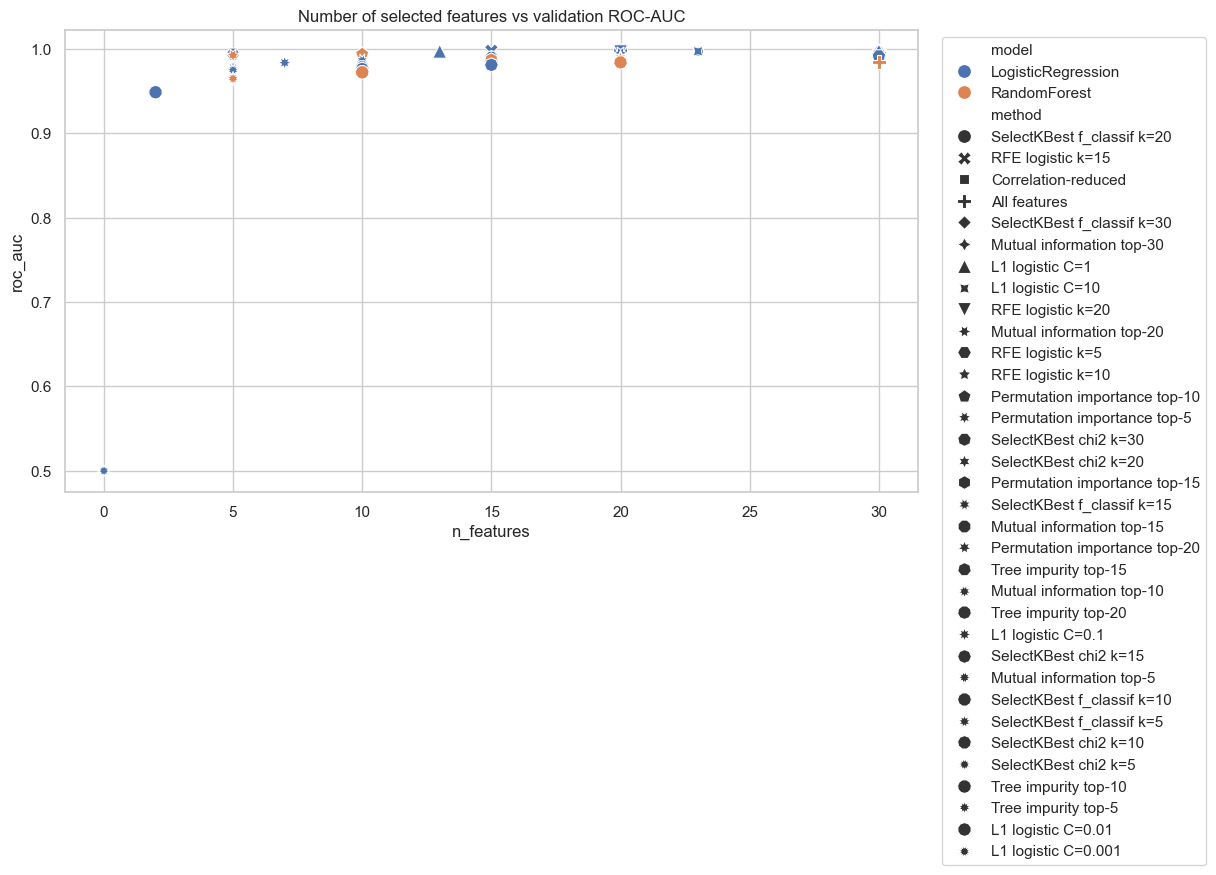

In [21]:
summary = comparison_table()
display(summary[["method", "model", "n_features", "accuracy", "precision", "recall", "f1", "roc_auc", "interpretation_note"]])

fig, ax = plt.subplots(figsize=(11, 6))
plot_df = summary.copy()
sns.scatterplot(data=plot_df, x="n_features", y="roc_auc", hue="model", style="method", s=100, ax=ax)
ax.set_title("Number of selected features vs validation ROC-AUC")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

### Do selection methods agree with each other?

Different feature-selection methods may achieve similar validation scores while selecting different variables. This does not automatically mean one method is wrong. It can mean the dataset contains correlated or interchangeable predictors. A Jaccard-overlap heatmap gives a compact view of agreement: values near 1 mean two methods selected very similar feature sets, while values near 0 mean little overlap.

,SelectKBest f_classif k=20,RFE logistic k=15,Correlation-reduced,All features,SelectKBest f_classif k=30,Mutual information top-30,L1 logistic C=1,L1 logistic C=10,RFE logistic k=20,Mutual information top-20,RFE logistic k=5,RFE logistic k=10
SelectKBest f_classif k=20,1.00,0.67,0.43,0.67,0.67,0.67,0.38,0.43,0.74,0.82,0.25,0.50
RFE logistic k=15,0.67,1.00,0.31,0.50,0.50,0.50,0.47,0.41,0.75,0.59,0.33,0.67
Correlation-reduced,0.43,0.31,1.00,0.77,0.77,0.77,0.44,0.84,0.43,0.43,0.08,0.22
All features,0.67,0.50,0.77,1.00,1.00,1.00,0.43,0.77,0.67,0.67,0.17,0.33
SelectKBest f_classif k=30,0.67,0.50,0.77,1.00,1.00,1.00,0.43,0.77,0.67,0.67,0.17,0.33
Mutual information top-30,0.67,0.50,0.77,1.00,1.00,1.00,0.43,0.77,0.67,0.67,0.17,0.33
L1 logistic C=1,0.38,0.47,0.44,0.43,0.43,0.43,1.00,0.50,0.50,0.32,0.29,0.35
L1 logistic C=10,0.43,0.41,0.84,0.77,0.77,0.77,0.50,1.00,0.48,0.43,0.17,0.32
RFE logistic k=20,0.74,0.75,0.43,0.67,0.67,0.67,0.50,0.48,1.00,0.67,0.25,0.50
Mutual information top-20,0.82,0.59,0.43,0.67,0.67,0.67,0.32,0.43,0.67,1.00,0.25,0.50


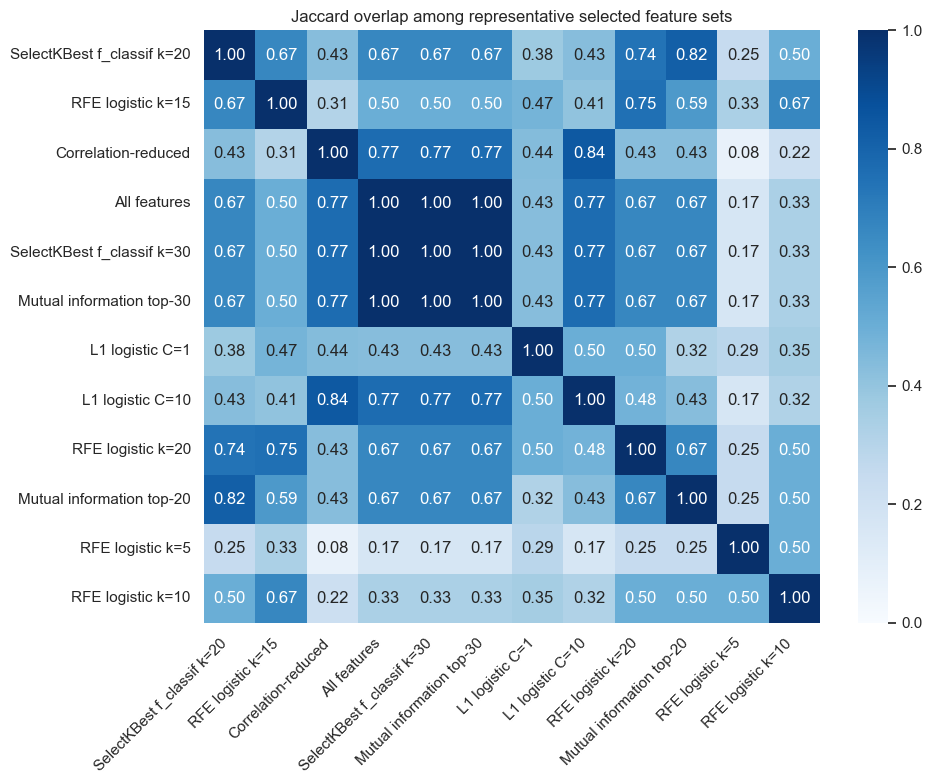

In [22]:
summary = comparison_table()
# Keep a readable subset of strong or representative methods.
representative = summary.drop_duplicates(subset=["method"]).head(12).copy()
selected_sets = {
    row["method"]: set(row["selected_features"])
    for _, row in representative.iterrows()
}

methods = list(selected_sets.keys())
jaccard = pd.DataFrame(index=methods, columns=methods, dtype=float)
for a in methods:
    for b in methods:
        union = selected_sets[a] | selected_sets[b]
        inter = selected_sets[a] & selected_sets[b]
        jaccard.loc[a, b] = len(inter) / len(union) if union else np.nan

display(jaccard.round(2))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(jaccard, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=ax)
ax.set_title("Jaccard overlap among representative selected feature sets")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Does fewer features improve generalization?

Feature selection may improve generalization, reduce overfitting, improve speed, or make a model easier to explain. It can also remove weak but useful signals, destabilize results, or produce biased interpretations if the selection process is not leakage-safe.

After running the comparison, check whether the reduced feature sets match or exceed the all-feature baseline. If the performance is similar, the smaller feature set may still be preferable because it is simpler.

## Error analysis

Two models can have similar ROC-AUC but make different mistakes. In medical-style applications, error type matters. A false negative and a false positive do not usually have the same consequence. The comparison below inspects the best all-feature model and the best selected-feature model by validation ROC-AUC.

Best all-feature candidate:


,method,model,n_features,roc_auc,f1
3,All features,LogisticRegression,30,0.9974,0.9787


Best selected-feature candidate:


,method,model,n_features,roc_auc,f1
0,SelectKBest f_classif k=20,LogisticRegression,20,0.9977,0.9787



All-feature model
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



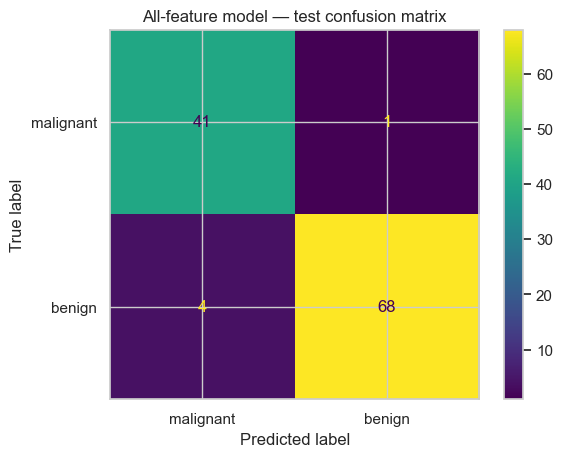

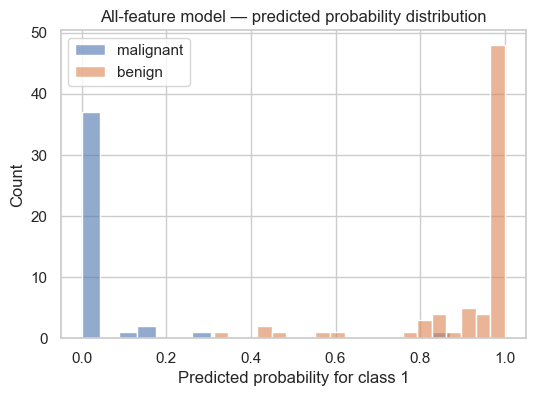


Selected-feature model
              precision    recall  f1-score   support

   malignant       0.91      0.98      0.94        42
      benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



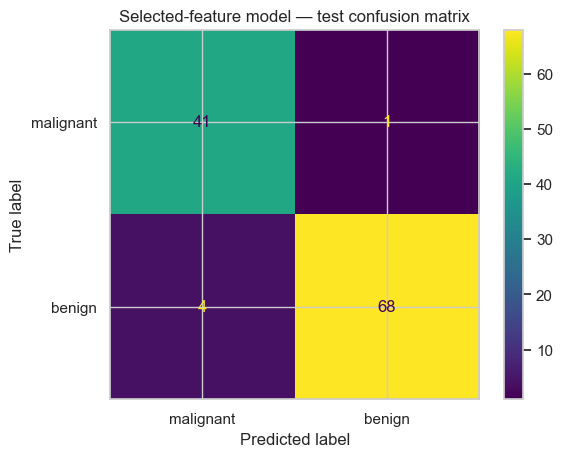

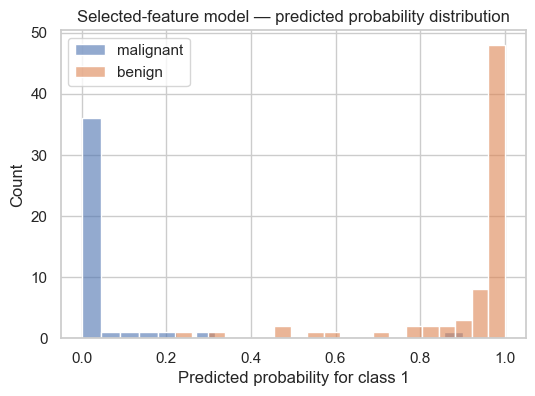

In [23]:
summary_for_choice = comparison_table()

# Best all-feature row and best selected-feature row by validation ROC-AUC.
best_all = summary_for_choice[summary_for_choice["method"].eq("All features")].iloc[0]
best_selected = summary_for_choice[~summary_for_choice["method"].eq("All features")].iloc[0]

print("Best all-feature candidate:")
display(best_all[["method", "model", "n_features", "roc_auc", "f1"]].to_frame().T)

print("Best selected-feature candidate:")
display(best_selected[["method", "model", "n_features", "roc_auc", "f1"]].to_frame().T)

def rebuild_model_from_row(row):
    selected = row["selected_features"]
    if row["model"] == "RandomForest":
        model = RandomForestClassifier(
            n_estimators=500, min_samples_leaf=2,
            class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=-1
        )
    else:
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))
        ])
    return selected, model

for label, row in [("All-feature model", best_all), ("Selected-feature model", best_selected)]:
    selected, model = rebuild_model_from_row(row)
    model.fit(X_train_full[selected], y_train_full)
    pred = model.predict(X_test[selected])
    proba = model.predict_proba(X_test[selected])[:, 1]

    print("\n" + label)
    print(classification_report(y_test, pred, target_names=data.target_names))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=data.target_names)
    plt.title(label + " — test confusion matrix")
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.histplot(proba[y_test == 0], bins=20, label=data.target_names[0], alpha=0.6, ax=ax)
    sns.histplot(proba[y_test == 1], bins=20, label=data.target_names[1], alpha=0.6, ax=ax)
    ax.set_title(label + " — predicted probability distribution")
    ax.set_xlabel("Predicted probability for class 1")
    ax.legend()
    plt.show()

## Important features are not necessarily causal features

Feature importance means that a trained model uses a feature for prediction. It does not prove that the feature causes the outcome. Correlated variables can act as proxies. Data collection bias can influence which variables appear important. A model may rely on a measurement because it is statistically useful in the dataset, even if the underlying causal mechanism is different.

Responsible interpretability combines model explanations with domain knowledge, study design, and awareness of how the data were collected. In high-risk settings, feature importance should support questions and audits; it should not be treated as standalone scientific proof.

## Interpretation and practical lessons

Filter methods such as correlation filtering and univariate scoring are fast and easy to understand, but they evaluate features in limited ways. Wrapper methods such as RFE are more model-aware but computationally heavier. Embedded methods such as L1 logistic regression select features as part of training, making them elegant but sensitive to scaling and regularization choices. Tree-based importance and permutation importance explain trained models, but they are affected by model structure and feature correlation.

Different methods may select different features because they answer different questions. After execution, compare whether features selected by L1 regularization overlap with those selected by permutation importance. Strong overlap suggests robust predictive relevance, while disagreement may indicate correlated or model-specific feature behavior.

The leakage demonstration, stability synthesis, and overlap heatmap add three practical checks beyond raw validation scores. A selected subset is more convincing when it is chosen inside a leakage-safe workflow, remains reasonably stable across splits, and has interpretable agreement with other importance views.

## Limitations

The Breast Cancer dataset is clean and small compared with messy real-world datasets. Feature importance is not causality. Some methods are sensitive to scaling. Feature selection performed outside cross-validation can leak information. Correlated features complicate interpretation because several variables may carry similar signals. SHAP and permutation importance explain a trained model, not the true data-generating process.

## What we learned

Feature selection reduces complexity but must be evaluated. Filter, wrapper, and embedded methods answer different questions. Regularization can select features by shrinking some coefficients to zero. Importance scores are model-dependent, and stability across splits matters. Interpretability requires caution because predictive usefulness, scientific meaning, and causal relevance are not the same thing.

## Possible extensions

Possible extensions include nested cross-validation for leakage-safe feature selection, stability selection, Boruta, SHAP interaction values, causal feature analysis, high-dimensional gene-expression data, fairness-aware feature selection, and model cards for documenting intended use and limitations.